In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler


In [3]:
DATA_PATH = r"C:\Users\gaoyu\OneDrive\Desktop\FINALPROJECT\UCI HAR Dataset"

features = pd.read_csv(f"{DATA_PATH}/features.txt", delim_whitespace=True, header=None)
feature_names = features.iloc[:, 1].values
activity_labels = pd.read_csv(f"{DATA_PATH}/activity_labels.txt", delim_whitespace=True, header=None, index_col=0)
activity_labels = activity_labels[1].to_dict()

X_train = pd.read_csv(f"{DATA_PATH}/train/X_train.txt", delim_whitespace=True, header=None)
y_train = pd.read_csv(f"{DATA_PATH}/train/y_train.txt", delim_whitespace=True, header=None)[0].map(activity_labels)
X_test = pd.read_csv(f"{DATA_PATH}/test/X_test.txt", delim_whitespace=True, header=None)
y_test = pd.read_csv(f"{DATA_PATH}/test/y_test.txt", delim_whitespace=True, header=None)[0].map(activity_labels)

X_train.columns = feature_names
X_test.columns = feature_names


In [4]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_names)
X_val = pd.DataFrame(scaler.transform(X_val_raw), columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)


In [6]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=30, min_samples_split=5, min_samples_leaf=3, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("🎯 Random Forest accuracy ratio:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


🎯 Random Forest accuracy ratio: 0.9270444519850696
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.92      0.89      0.90       491
          STANDING       0.90      0.93      0.91       532
           WALKING       0.89      0.98      0.93       496
WALKING_DOWNSTAIRS       0.96      0.83      0.89       420
  WALKING_UPSTAIRS       0.90      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



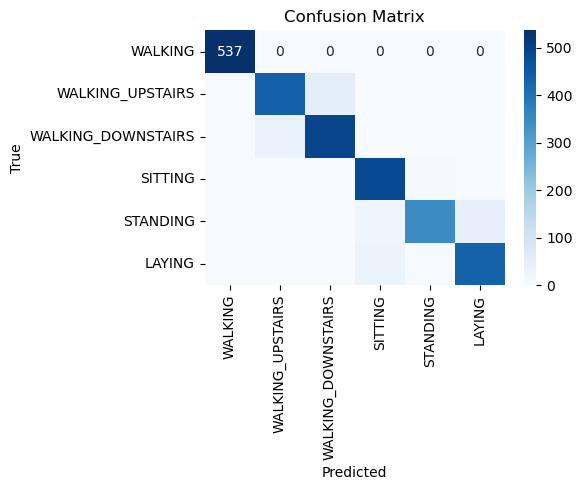

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=activity_labels.values(), yticklabels=activity_labels.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


In [7]:
models = {
    'Random Forest': rf_model,
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier()
}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, pred):.2f}")


Random Forest accuracy: 0.93
SVM accuracy: 0.95
Decision Tree accuracy: 0.85


Random Forest CV Mean Accuracy: 0.977
SVM CV Mean Accuracy: 0.977
Decision Tree CV Mean Accuracy: 0.935


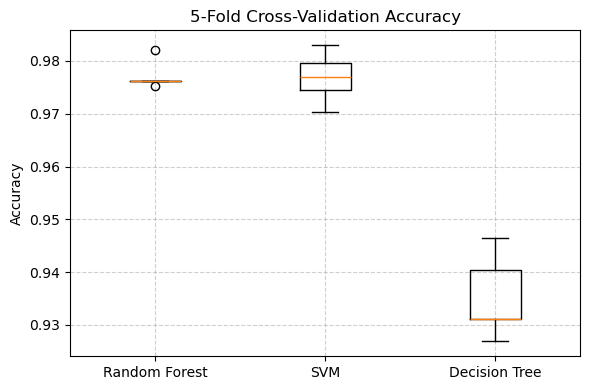

In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_scores[name] = scores
    print(f"{name} CV Mean Accuracy: {scores.mean():.3f}")

# 可视化
plt.figure(figsize=(6, 4))
plt.boxplot(cv_scores.values(), labels=cv_scores.keys())
plt.title("5-Fold Cross-Validation Accuracy")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("cv_boxplot.png")
plt.show()


In [8]:
acc_features = [f for f in feature_names if 'Acc' in f and 'fBody' not in f]
gyro_features = [f for f in feature_names if 'Gyro' in f and 'fBody' not in f]
fft_features = [f for f in feature_names if 'fBody' in f]
angle_features = [f for f in feature_names if 'angle' in f]

for name, subset in zip(['Acceleration', 'Gyroscope', 'Frequency', 'Angle'],
                        [acc_features, gyro_features, fft_features, angle_features]):
    rf_model.fit(X_train[subset], y_train)
    acc = accuracy_score(y_test, rf_model.predict(X_test[subset]))
    print(f" Accuracy using only {name} feature:{acc:.3f}")


 Accuracy using only Acceleration feature:0.885
 Accuracy using only Gyroscope feature:0.767
 Accuracy using only Frequency feature:0.873
 Accuracy using only Angle feature:0.663


In [15]:
# Perform Grid Search to find optimal hyperparameters for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100],  # 先固定数量
    'max_depth': [20],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 3]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_


Best parameters found by GridSearchCV: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [9]:
# === Retrain a full-feature Random Forest model to avoid being overwritten ===
full_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
full_rf_model.fit(X_train, y_train)

# === Add Gaussian noise to the test set for robustness evaluation ===
X_test_noisy = X_test + np.random.normal(0, 0.05, X_test.shape)
X_test_noisy = pd.DataFrame(X_test_noisy, columns=X_test.columns)

# === Evaluate the model under noisy input ===
print("Accuracy after adding Gaussian noise:", accuracy_score(y_test, full_rf_model.predict(X_test_noisy)))

# === Train a new model using only the top 100 features (for model compression) ===
X_train_partial = X_train.iloc[:, :100]  # Use first 100 features
X_test_partial = X_test.iloc[:, :100]

rf_model.fit(X_train_partial, y_train)

# === Evaluate compressed model ===
print("Accuracy using only top 100 features:", accuracy_score(y_test, rf_model.predict(X_test_partial)))


Accuracy after adding Gaussian noise: 0.9263657957244655
Accuracy using only top 100 features: 0.8839497794367153


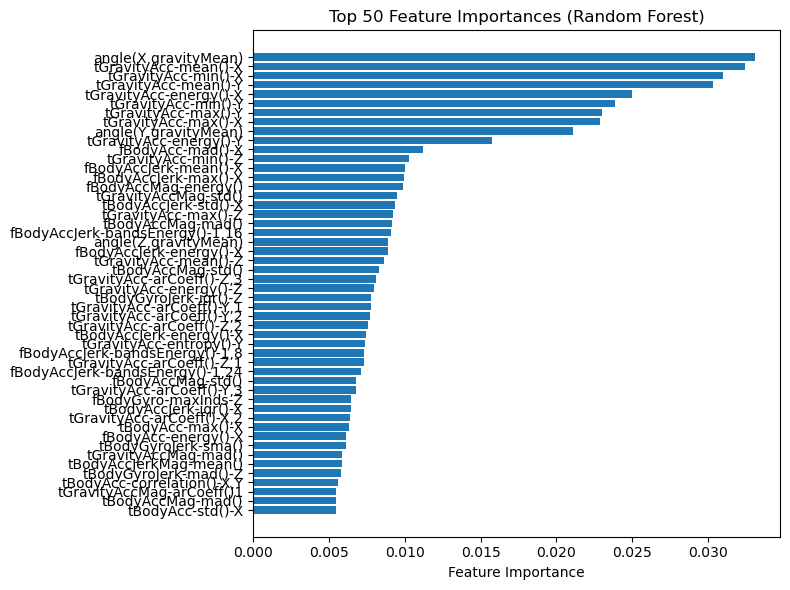

In [14]:
# Visualize top-50 important features from the trained model
importances = full_rf_model.feature_importances_
indices = np.argsort(importances)[-50:]

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 50 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig('feature_importance_top50.png')
plt.show()


<Figure size 640x480 with 0 Axes>

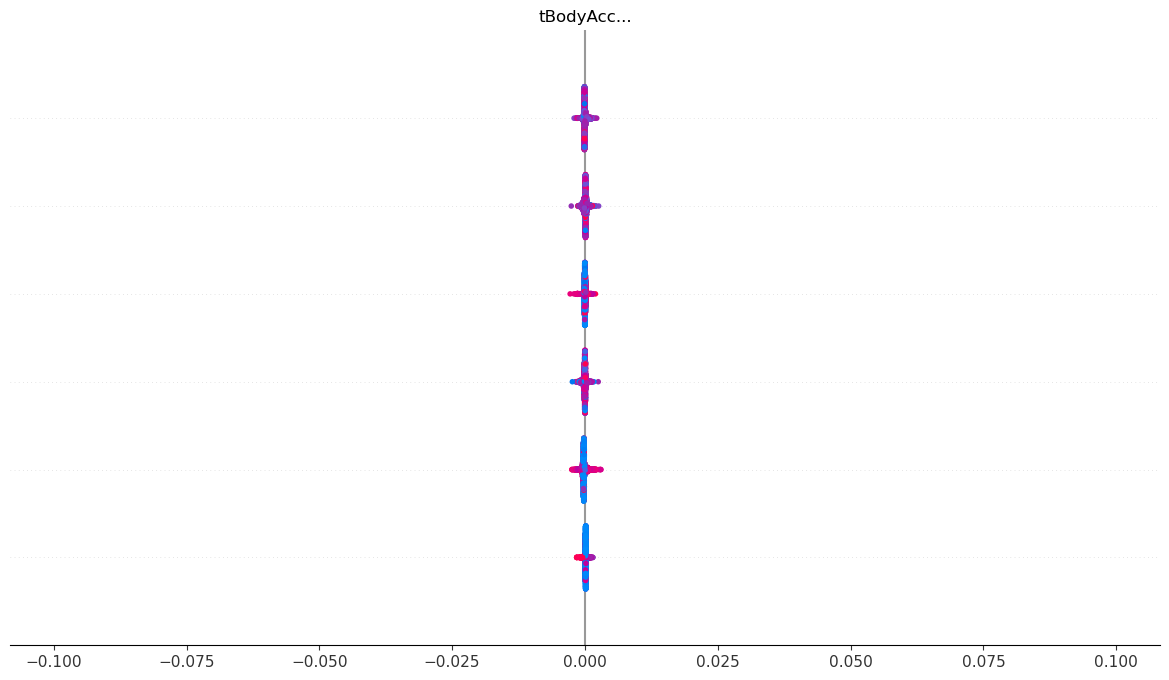

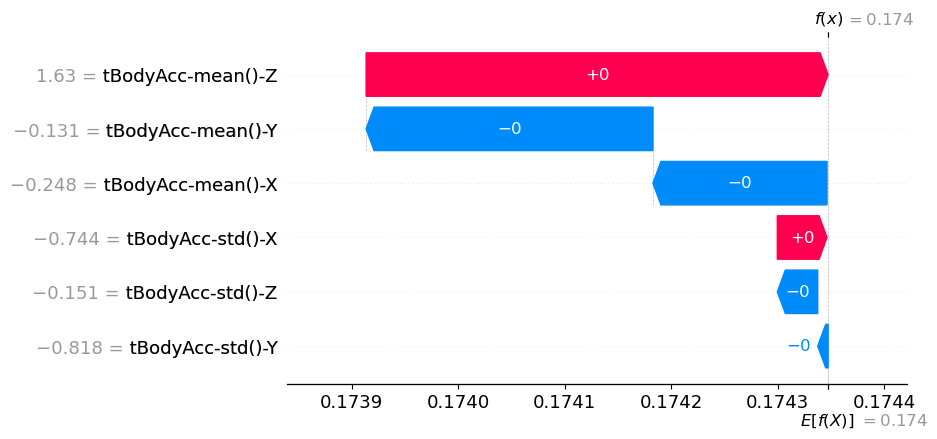

In [10]:
# === Install SHAP (if not already installed) ===
# pip install shap

# === Use the trained full-feature Random Forest model for SHAP explanation ===
explainer = shap.TreeExplainer(full_rf_model)

# === Compute SHAP values on the test set ===
shap_values = explainer.shap_values(X_test)

# === Generate and display the summary plot (global feature importance ranking) ===
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

# === Save the summary plot as an image ===
plt.savefig('shap_summary_plot.png')
plt.close()

# === Generate the waterfall plot (local explanation for a single sample) ===
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],  # SHAP values for class 1
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

# === Save the waterfall plot as an image ===
plt.savefig('shap_waterfall_plot.png')
plt.close()
